### Model Evaluation Visualizations

This notebook evaluates the trained photo editing suggestion model and creates visualizations for better readability and analysis.

In [1]:
from pathlib import Path

project_dir = Path.cwd()
print(project_dir)
print((project_dir / "data").exists())
print((project_dir / "checkpoints/suggestions/best.pt").exists())

/Users/chengbangliu/Desktop/142b_final/Harrison-and-Jerry-s-photo-proj
True
True


In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import DataLoader

from fivek_project.dataset import FiveKSuggestionDataset
from fivek_project.suggestion_model import build_suggestion_model
from fivek_project.suggestions import EDIT_NAMES
from train import pick_device

In [3]:
data_dir = "data"
checkpoint_path = "checkpoints/suggestions/best.pt"
batch_size = 8

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

device = pick_device()
device

device(type='mps')

In [4]:
model = build_suggestion_model(pretrained=False).to(device)

saved = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(saved["model"])
model.eval()

print("Loaded checkpoint from epoch:", saved["epoch"])
print("Best validation loss:", saved["val_loss"])

Loaded checkpoint from epoch: 15
Best validation loss: 0.011369917392730713


In [5]:
def get_predictions(split):
    dataset = FiveKSuggestionDataset(data_dir, split)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    preds, targets = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs.to(device)).cpu()
            preds.append(outputs)
            targets.append(labels)

    return torch.cat(preds), torch.cat(targets)

In [6]:
test_preds, test_targets = get_predictions("test")

print(test_preds.shape)
print(test_targets.shape)

torch.Size([100, 8])
torch.Size([100, 8])


In [7]:
errors = test_preds - test_targets

mae = errors.abs().mean(dim=0)
rmse = torch.sqrt((errors ** 2).mean(dim=0))
smooth_l1 = torch.nn.functional.smooth_l1_loss(test_preds, test_targets).item()

metrics_df = pd.DataFrame({
    "edit_label": EDIT_NAMES,
    "mae": mae.numpy(),
    "rmse": rmse.numpy()
})

print("Test Smooth L1 Loss:", round(smooth_l1, 4))
metrics_df

Test Smooth L1 Loss: 0.0141


,edit_label,mae,rmse
0,brightness,0.163491,0.208521
1,contrast,0.073705,0.095943
2,highlights,0.158487,0.293942
3,shadows,0.065714,0.109756
4,temperature,0.123083,0.165084
5,tint,0.050159,0.069827
6,saturation,0.139471,0.189184
7,clarity,0.063060,0.082331


In [8]:
metrics_df.to_csv(results_dir / "test_metrics_by_label.csv", index=False)

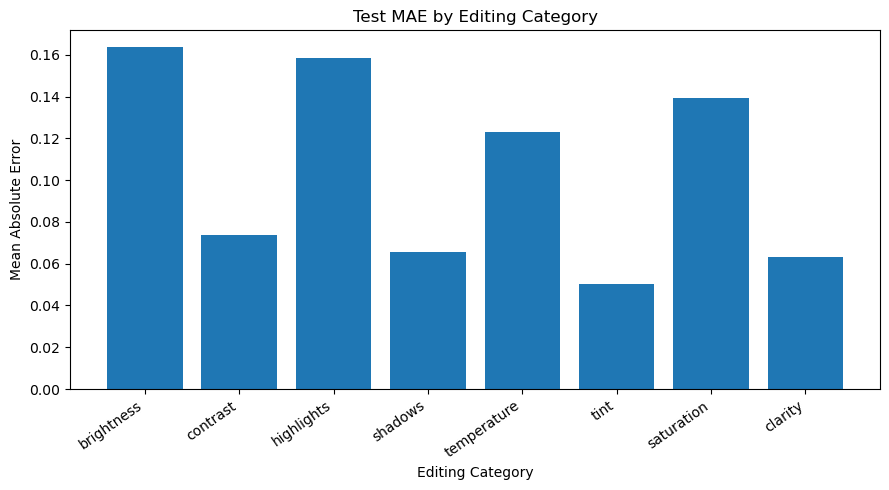

In [9]:
plt.figure(figsize=(9, 5))
plt.bar(metrics_df["edit_label"], metrics_df["mae"])
plt.xlabel("Editing Category")
plt.ylabel("Mean Absolute Error")
plt.title("Test MAE by Editing Category")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(results_dir / "test_mae_by_label.png", dpi=200)
plt.show()

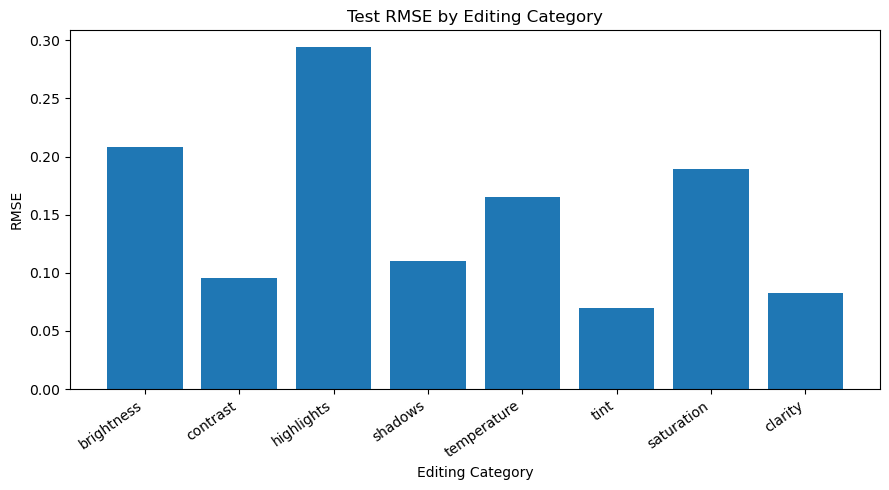

In [10]:
plt.figure(figsize=(9, 5))
plt.bar(metrics_df["edit_label"], metrics_df["rmse"])
plt.xlabel("Editing Category")
plt.ylabel("RMSE")
plt.title("Test RMSE by Editing Category")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(results_dir / "test_rmse_by_label.png", dpi=200)
plt.show()

In [11]:
threshold = 0.06

pred_dir = torch.where(test_preds > threshold, 1, torch.where(test_preds < -threshold, -1, 0))
target_dir = torch.where(test_targets > threshold, 1, torch.where(test_targets < -threshold, -1, 0))

direction_accuracy = (pred_dir == target_dir).float().mean(dim=0)

direction_df = pd.DataFrame({
    "edit_label": EDIT_NAMES,
    "direction_accuracy": direction_accuracy.numpy()
})

direction_df

,edit_label,direction_accuracy
0,brightness,0.44
1,contrast,0.41
2,highlights,0.41
3,shadows,0.60
4,temperature,0.57
5,tint,0.68
6,saturation,0.47
7,clarity,0.53


In [13]:
split_losses = []

for split in ["train", "val", "test"]:
    preds, targets = get_predictions(split)
    loss = torch.nn.functional.smooth_l1_loss(preds, targets).item()
    split_losses.append({"split": split, "smooth_l1_loss": loss})

split_loss_df = pd.DataFrame(split_losses)
split_loss_df

,split,smooth_l1_loss
0,train,0.002256
1,val,0.011370
2,test,0.014068


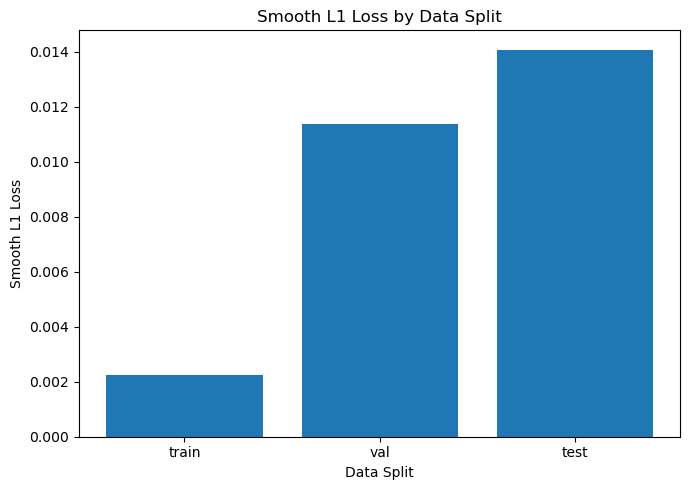

In [14]:
plt.figure(figsize=(7, 5))
plt.bar(split_loss_df["split"], split_loss_df["smooth_l1_loss"])
plt.xlabel("Data Split")
plt.ylabel("Smooth L1 Loss")
plt.title("Smooth L1 Loss by Data Split")
plt.tight_layout()
plt.savefig(results_dir / "smooth_l1_by_split.png", dpi=200)
plt.show()

In [15]:
epochs = list(range(1, 16))

train_loss = [
    0.0184, 0.0101, 0.0080, 0.0066, 0.0057,
    0.0050, 0.0047, 0.0044, 0.0041, 0.0037,
    0.0037, 0.0035, 0.0034, 0.0034, 0.0031
]

val_loss = [
    0.0158, 0.0135, 0.0132, 0.0133, 0.0128,
    0.0131, 0.0137, 0.0133, 0.0131, 0.0126,
    0.0126, 0.0142, 0.0127, 0.0143, 0.0128
]

loss_curve_df = pd.DataFrame({
    "epoch": epochs,
    "train_loss": train_loss,
    "val_loss": val_loss
})

loss_curve_df

,epoch,train_loss,val_loss
0,1,0.0184,0.0158
1,2,0.0101,0.0135
2,3,0.0080,0.0132
3,4,0.0066,0.0133
4,5,0.0057,0.0128
5,6,0.0050,0.0131
6,7,0.0047,0.0137
7,8,0.0044,0.0133
8,9,0.0041,0.0131
9,10,0.0037,0.0126


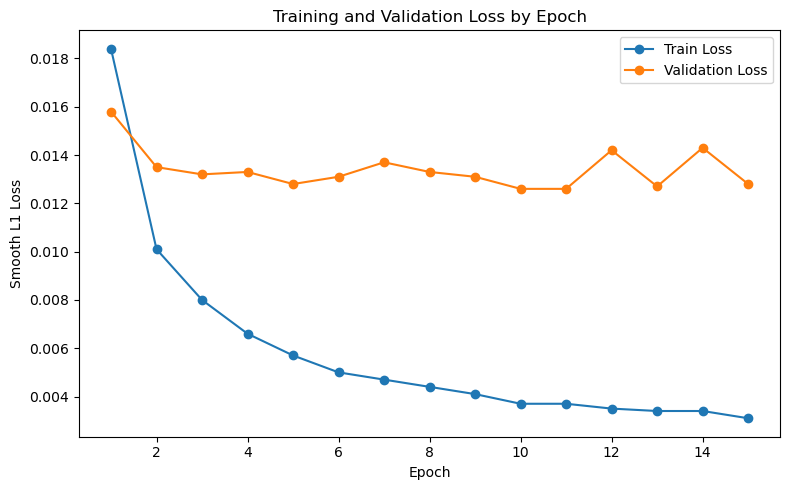

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(loss_curve_df["epoch"], loss_curve_df["train_loss"], marker="o", label="Train Loss")
plt.plot(loss_curve_df["epoch"], loss_curve_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Smooth L1 Loss")
plt.title("Training and Validation Loss by Epoch")
plt.legend()
plt.tight_layout()
plt.savefig(results_dir / "training_validation_loss_curve.png", dpi=200)
plt.show()

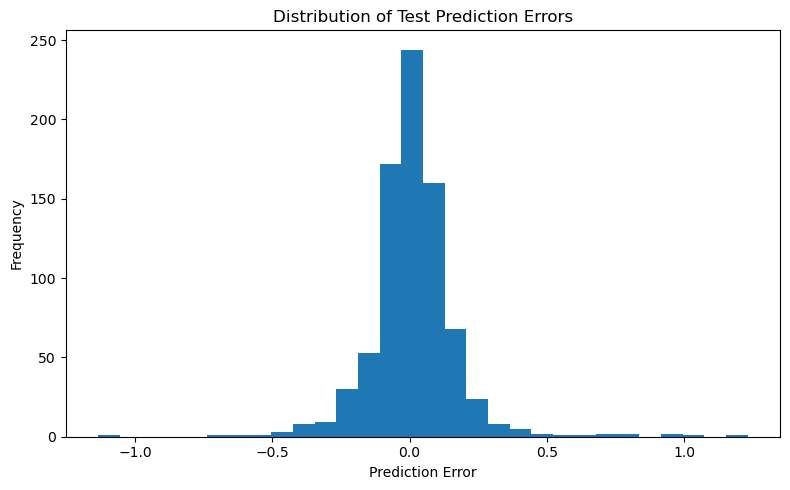

In [17]:
all_errors = errors.flatten().numpy()

plt.figure(figsize=(8, 5))
plt.hist(all_errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Test Prediction Errors")
plt.tight_layout()
plt.savefig(results_dir / "test_error_distribution.png", dpi=200)
plt.show()

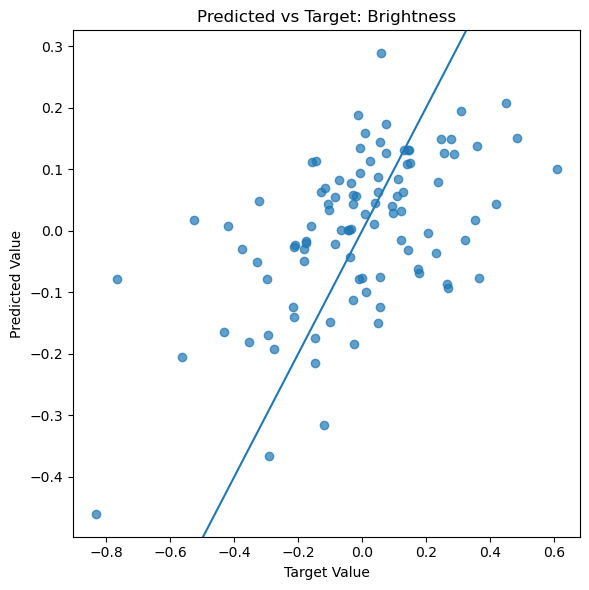

In [18]:
plot_label = "brightness"
label_index = EDIT_NAMES.index(plot_label)

plt.figure(figsize=(6, 6))
plt.scatter(test_targets[:, label_index], test_preds[:, label_index], alpha=0.7)
plt.xlabel("Target Value")
plt.ylabel("Predicted Value")
plt.title(f"Predicted vs Target: {plot_label.title()}")
plt.axline((0, 0), slope=1)
plt.tight_layout()
plt.savefig(results_dir / f"predicted_vs_target_{plot_label}.png", dpi=200)
plt.show()